## **Convolutional Neural Network Model [CNN], Image Classification**

#### **Import Important python/CNN liberies**

In [1]:
# import import CNN libraries

import numpy as np
import matplotlib.pyplot as plt

#%matpltlib inline

# importing tensorflow and its dependencies
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.applications.xception import preprocess_input

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### **Packages used and their versions**  
**matplotlib version     3.10.6**  
**Pandas version         2.3.3**  
**numpy version          2.3.5**  
**tensorflow version     2.32.0**

#### **Import Sample Data for Dataset Exploration**

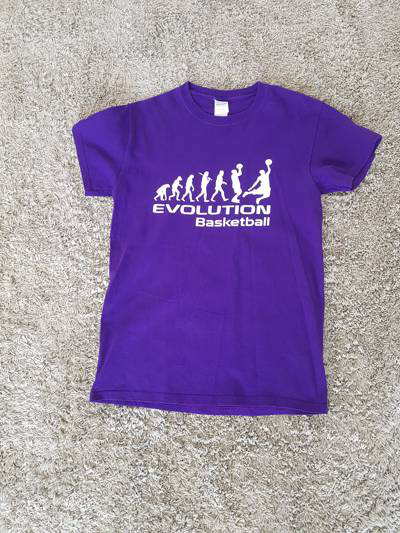

In [2]:
# Displaying a sample raw train dataset
path = r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\train\t-shirt'
name = '00d9cc6e-2564-4813-9d68-4bc4d562107b.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

In [3]:
# converting the image into a numpy array and displaying it shape
img = load_img(fullname, target_size = (299, 299))

x = np.array(img)
x.shape

(299, 299, 3)

#### **The Training Dataset**
#### The size of the data/image was reduced here in order to make training faster

In [74]:
# importing the training dataset
# instantiate the imagedatagenerator

train_gen = ImageDataGenerator(preprocessing_function = preprocess_input)

train_ds = train_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\train',
    target_size = (150, 150),
    batch_size = 34
)

Found 3068 images belonging to 10 classes.


In [5]:
# The 10 classes in the dataset
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [80]:
# the X & y variables [predictor & target variables] of the train dataset
X, y = next(train_ds)
print(X.shape)
print(y[1])
X[0]

(34, 150, 150, 3)
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


array([[[-0.5686275 , -0.6156863 , -0.70980394],
        [-0.5529412 , -0.6       , -0.69411767],
        [-0.5529412 , -0.6       , -0.69411767],
        ...,
        [-0.52156866, -0.5686275 , -0.6627451 ],
        [-0.54509807, -0.5921569 , -0.6862745 ],
        [-0.4980392 , -0.54509807, -0.6392157 ]],

       [[-0.5764706 , -0.62352943, -0.7176471 ],
        [-0.5686275 , -0.6156863 , -0.70980394],
        [-0.56078434, -0.60784316, -0.7019608 ],
        ...,
        [-0.6862745 , -0.73333335, -0.827451  ],
        [-0.6627451 , -0.70980394, -0.8039216 ],
        [-0.64705884, -0.69411767, -0.7882353 ]],

       [[-0.6       , -0.64705884, -0.7411765 ],
        [-0.5529412 , -0.6       , -0.69411767],
        [-0.56078434, -0.60784316, -0.7019608 ],
        ...,
        [-0.5058824 , -0.5529412 , -0.64705884],
        [-0.75686276, -0.8039216 , -0.8980392 ],
        [-0.7411765 , -0.7882353 , -0.88235295]],

       ...,

       [[ 0.254902  ,  0.19215691,  0.02745104],
        [ 0

#### **The Validation dataset**

In [7]:
# the validation dataset

val_gen = ImageDataGenerator(preprocessing_function = preprocess_input)

val_ds = val_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\validation',
    target_size = (150, 150),
    batch_size = 34,
    shuffle = False
)

Found 341 images belonging to 10 classes.


**The Initial Model Composition**

In [8]:
# initiating the base model
base_model = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

base_model.trainable = False

In [9]:
# Initial Model composition
inputs = keras.Input(shape = (150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [10]:
# compiling the model using optimizers & loss function
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits = True)

model.compile(
    optimizer = optimizer,
    loss = loss,
    metrics = ['accuracy']
)

In [11]:
# the real training of the model
history = model.fit(train_ds, epochs = 10, validation_data = val_ds)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6591 - loss: 1.2626 - val_accuracy: 0.7830 - val_loss: 0.8144
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8198 - loss: 0.5693 - val_accuracy: 0.7859 - val_loss: 0.7202
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8862 - loss: 0.3351 - val_accuracy: 0.7683 - val_loss: 1.0231
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9221 - loss: 0.2252 - val_accuracy: 0.8035 - val_loss: 0.8957
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9371 - loss: 0.1863 - val_accuracy: 0.7889 - val_loss: 0.9626
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9573 - loss: 0.1218 - val_accuracy: 0.8094 - val_loss: 0.9068
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9687 - loss: 0.0888 - val_accuracy: 0.8240 - val_loss: 0.7858
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9798 - loss: 0.0628 - val_accuracy: 0.8182 - v

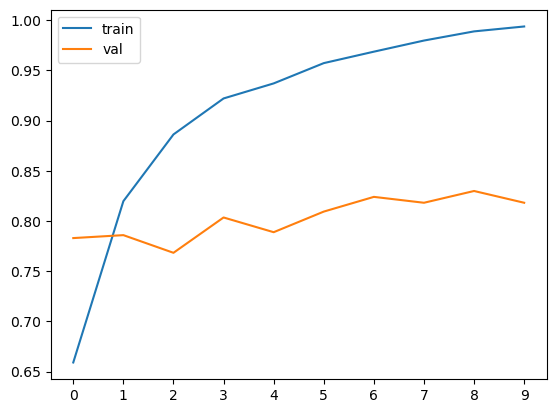

In [12]:
# plot of the accuracy of the train and validation set
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'val')

plt.xticks(np.arange(10))
plt.legend()

#### **Hyperparameter Training to Get The Optimal Learning_Rate**
**Initiating a function for the training model**

In [13]:
# Definig the function to create the cnn model
def make_model(learning_rate = 0.01):
    base_model = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
    )

    base_model.trainable = False

    ##########################################################

    inputs = keras.Input(shape = (150, 150, 3))
    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    ##########################################################

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer, 
        loss = loss, 
        metrics = ['accuracy']
    )
    return model

In [14]:
# fitting the data to get the best learning rate parameter
scores = {}

for lr in [0.001, 0.01, 0.1]:                  
    print(lr)

    model = make_model(learning_rate = lr)
    history = model.fit(train_ds, epochs = 10, validation_data = val_ds)
    scores[lr] = history.history

    print()
    print()


0.001
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.6346 - loss: 1.0858 - val_accuracy: 0.7507 - val_loss: 0.7147
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7771 - loss: 0.6342 - val_accuracy: 0.8006 - val_loss: 0.6154
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8347 - loss: 0.5141 - val_accuracy: 0.8065 - val_loss: 0.5760
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8579 - loss: 0.4391 - val_accuracy: 0.8152 - val_loss: 0.5762
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8820 - loss: 0.3812 - val_accuracy: 0.8152 - val_loss: 0.5540
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9032 - loss: 0.3309 - val_accuracy: 0.8270 - val_loss: 0.5335
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9159 - loss: 0.2997 - val_accuracy: 0.8358 - val_loss: 0.5278
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9335 - loss: 0.2664 - val_accuracy: 0.83

In [15]:
# viewing the variables obtained during training for the optimal learning rate
for lr, hist in scores.items():
    print(lr)
    print(hist)

0.001
{'accuracy': [0.6346153616905212, 0.7770534753799438, 0.8347457647323608, 0.857887864112854, 0.8820078372955322, 0.9031942486763, 0.9159061312675476, 0.9335071444511414, 0.942307710647583, 0.9485006332397461], 'loss': [1.0857936143875122, 0.6342418193817139, 0.5140581130981445, 0.43913036584854126, 0.38116416335105896, 0.33085498213768005, 0.29969924688339233, 0.2663717567920685, 0.23772405087947845, 0.21960419416427612], 'val_accuracy': [0.7507331371307373, 0.8005865216255188, 0.8064516186714172, 0.8152492642402649, 0.8152492642402649, 0.8269794583320618, 0.8357771039009094, 0.8328445553779602, 0.829912006855011, 0.8152492642402649], 'val_loss': [0.7147019505500793, 0.6154481172561646, 0.5759760737419128, 0.5761661529541016, 0.553973376750946, 0.533534586429596, 0.5277606844902039, 0.5265965461730957, 0.5228372812271118, 0.5326051712036133]}
0.01
{'accuracy': [0.665580153465271, 0.8158409595489502, 0.8846153616905212, 0.908083438873291, 0.9325293302536011, 0.9439374208450317, 0.

#### **Accuracy of the validation and training datasets for different learning rates**

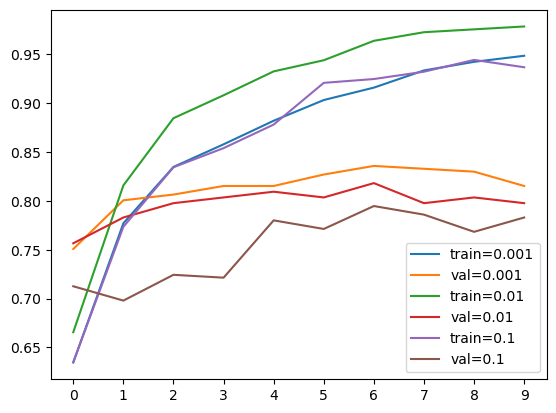

In [16]:
# Accuracy of both validation and training datasets for different learning rates

for lr, hist in scores.items():
    plt.plot(hist['accuracy'], label = ('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label = ('val=%s' % lr))


plt.xticks(np.arange(10))
plt.legend()

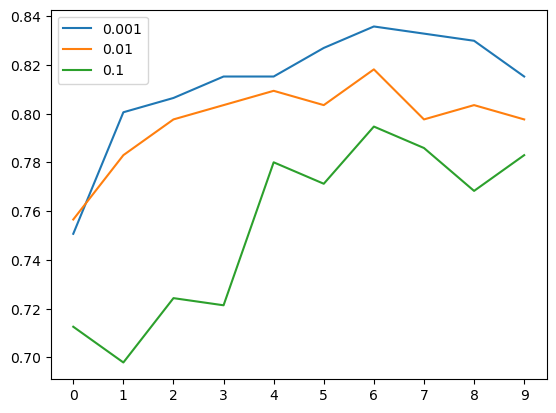

In [17]:
# Plot of different learning rate for the validation dataset

for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label = lr)

plt.xticks(np.arange(10))
plt.legend()

**The validation data has the higest accuracy when learning rate is 0.001 as shown in the graph above**  

#### **CheckPointing to save the Model at points it achieved its best performance(after each iteration)**

In [18]:
# model.save_weights('model_v1.h5', save_format='h5'), old way of doing it.
model.save_weights('my_model.weights.h5')

In [19]:
# format checkpoint naming convention
'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5'.format(epoch=3, val_accuracy = 0.84)

'xception_v1_03_0.840.h5'

In [20]:
# Declaring the checkpoint variables
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only = True,
    monitor = 'val_accuracy',
    mode = 'max'    
)

In [21]:
# Training/fitting the model for checkpoins
learning_rate = 0.001

model = make_model(learning_rate = learning_rate)

history = model.fit(
    train_ds, 
    epochs = 10, 
    validation_data = val_ds,
    callbacks = [checkpoint]
)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6366 - loss: 1.0839

91/91 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6366 - loss: 1.0839 - val_accuracy: 0.7566 - val_loss: 0.7510
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7832 - loss: 0.6330

91/91 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.7832 - loss: 0.6330 - val_accuracy: 0.8006 - val_loss: 0.6469
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8253 - loss: 0.5139 - val_accuracy: 0.7947 - val_loss: 0.6266
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8611 - loss: 0.4294

91/91 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8611 - loss: 0.4294 - val_accuracy: 0.8182 - val_loss: 0.5761
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8889 - loss: 0.3742 - val_accuracy: 0.8152 - val_loss: 0.5507
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9035 - loss: 0.3313 - val_accuracy: 0.8065 - val_loss: 0.5597
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9169 - loss: 0.2943 - val_accuracy: 0.8182 - val_loss: 0.5354
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9289 - loss: 0.2655 - val_accuracy: 0.8035 - val_loss: 0.5647
Epoch 9/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9426 - loss: 0.2400 - val_accuracy: 0.8123 - val_loss: 0.5737
Epoch 10/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9501 - loss: 0.2181

91/91 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9501 - loss: 0.2181 - val_accuracy: 0.8387 - val_loss: 0.5347


#### **Add a Hidden/Inner layer to the Model, the hyperparameter gives the size of the inner Layer for model optimal accuracy**

In [22]:
# size_inner is added to the parameter of the defined function
# relu is used as the default activation function
def make_model(learning_rate = 0.01, size_inner = 100):
    base_model = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
    )

    base_model.trainable = False

    ##########################################################

    inputs = keras.Input(shape = (150, 150, 3))
    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation = 'relu')(vectors)
    
    outputs = keras.layers.Dense(10)(inner)
    
    model = keras.Model(inputs, outputs)

    ##########################################################

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer, 
        loss = loss, 
        metrics = ['accuracy']
    )
    return model

In [23]:
# fitting the model for the hidden layer size
scores = {}
learning_rate = 0.001

for size in [10, 100, 200]:
    print(size)

    model = make_model(learning_rate, size_inner = size)
    history = model.fit(train_ds, epochs = 10, validation_data = val_ds)
    scores[size] = history.history

    print()
    print()    

10
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.4873 - loss: 1.5879 - val_accuracy: 0.6393 - val_loss: 1.2032
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.6900 - loss: 0.9945 - val_accuracy: 0.7449 - val_loss: 0.8690
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7581 - loss: 0.7440 - val_accuracy: 0.7713 - val_loss: 0.7610
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8035 - loss: 0.6163 - val_accuracy: 0.7713 - val_loss: 0.7158
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8295 - loss: 0.5307 - val_accuracy: 0.7918 - val_loss: 0.6539
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8432 - loss: 0.4651 - val_accuracy: 0.8094 - val_loss: 0.6198
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8774 - loss: 0.3971 - val_accuracy: 0.8035 - val_loss: 0.5903
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9003 - loss: 0.3432 - val_accuracy: 0.7977 

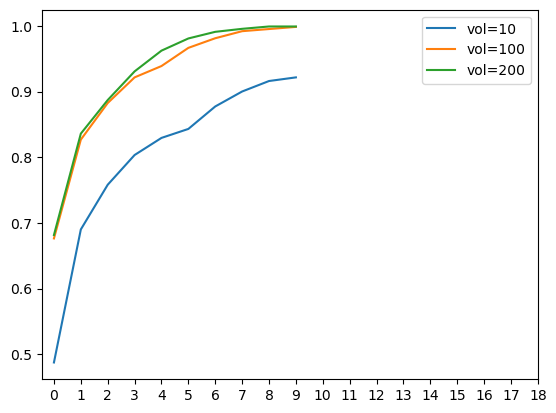

In [24]:
# train dataset plot for the hidden layer size 
for size, hist in scores.items():
    plt.plot(hist['accuracy'], label = ('vol=%s' % size))

plt.xticks(np.arange(19)) 
plt.legend()

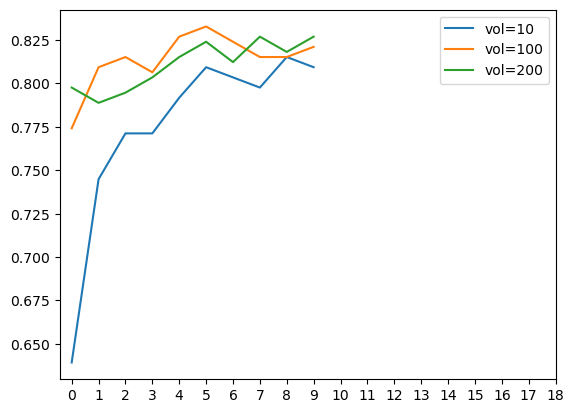

In [25]:
# Validation dataset plot for the hidden layer size 
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label = ('vol=%s' % size))

plt.xticks(np.arange(19)) 
plt.legend()

**The validation data has the higest accuracy when the size of the hidden/inner layer is 100 as shown in the graph above**  


#### **Regularization: Traning for the Optimal Hyperparameter of the Dropout**

In [32]:
# the dropout layer is added to the Model function
def make_model(learning_rate = 0.01, size_inner = 100, droprate = 0.50):
    base_model = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
    )

    base_model.trainable = False

    ##########################################################

    inputs = keras.Input(shape = (150, 150, 3))
    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation = 'relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)

    ##########################################################

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer, 
        loss = loss, 
        metrics = ['accuracy']
    )
    return model

In [33]:
# Fitting the model for droprate optimization
scores = {}

learning_rate = 0.001
size_inner = 100

for droprate in [0.0, 0.2, 0.6]:
    print(droprate)

    model = make_model(
        learning_rate = learning_rate, 
        size_inner = size_inner, 
        droprate = droprate
    )
    history = model.fit(train_ds, epochs = 10, validation_data = val_ds)
    scores[droprate] = history.history

    print()
    print()    

0.0
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6786 - loss: 0.9609 - val_accuracy: 0.7801 - val_loss: 0.6773
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8178 - loss: 0.5302 - val_accuracy: 0.8123 - val_loss: 0.5424
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8726 - loss: 0.3710 - val_accuracy: 0.8182 - val_loss: 0.5429
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.9247 - loss: 0.2575 - val_accuracy: 0.8182 - val_loss: 0.5470
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9465 - loss: 0.1948 - val_accuracy: 0.8152 - val_loss: 0.5853
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.9593 - loss: 0.1518 - val_accuracy: 0.8270 - val_loss: 0.5546
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9824 - loss: 0.0985 - val_accuracy: 0.8123 - val_loss: 0.6139
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9853 - loss: 0.0854 - val_accuracy: 0.8270

#### **Plot for the optimal droprate hyperparameter**

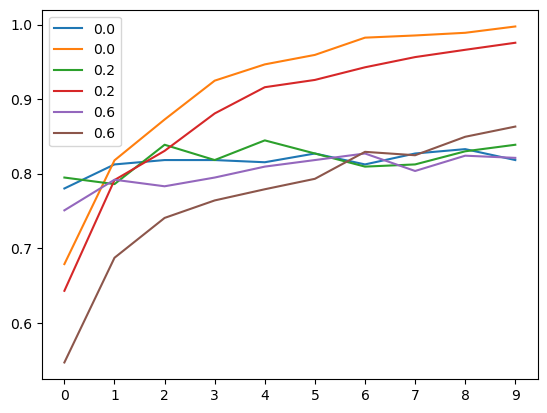

In [34]:
# combination of the train dataset accuracy and validation dataset accuracy
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label = droprate)
    plt.plot(hist['accuracy'], label = droprate)

plt.xticks(np.arange(10))
plt.legend()

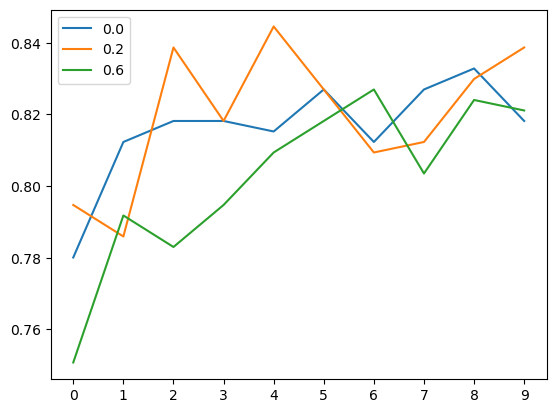

In [35]:
# val_accuracy graph
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label = droprate)

plt.xticks(np.arange(10))
plt.legend()
    

#### **According to val_accuracy plot above, the Best Droprate is 20% or 0.2**  

### **Data Augumentation, This Involves Different Transformation Methods**

In [37]:
# Data augumentation to prevent overfitting
train_gen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    shear_range = 10.0,
    zoom_range = 0.1,
    vertical_flip = True
)

train_ds = train_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\train', 
    target_size = (150, 150), 
    batch_size = 34
)

# for the validation dataset
val_gen = ImageDataGenerator(preprocessing_function = preprocess_input)

val_ds = val_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\validation', 
    target_size = (150, 150), 
    batch_size = 34,
    shuffle = False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [38]:
# Training the model that included augumented data
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate = learning_rate, 
    size_inner = size,
    droprate = droprate
)
history = model.fit(train_ds, epochs = 18, validation_data = val_ds)

Epoch 1/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5701 - loss: 1.3100 - val_accuracy: 0.7331 - val_loss: 0.7534
Epoch 2/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6910 - loss: 0.9110 - val_accuracy: 0.7625 - val_loss: 0.6861
Epoch 3/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7360 - loss: 0.7696 - val_accuracy: 0.7713 - val_loss: 0.6418
Epoch 4/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7513 - loss: 0.7070 - val_accuracy: 0.7595 - val_loss: 0.6705
Epoch 5/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7722 - loss: 0.6651 - val_accuracy: 0.8065 - val_loss: 0.5971
Epoch 6/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7979 - loss: 0.5886 - val_accuracy: 0.8152 - val_loss: 0.5733
Epoch 7/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8100 - loss: 0.5536 - val_accuracy: 0.7947 - val_loss: 0.5921
Epoch 8/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8152 - loss: 0.5284 - val_accuracy: 0.8065 - v

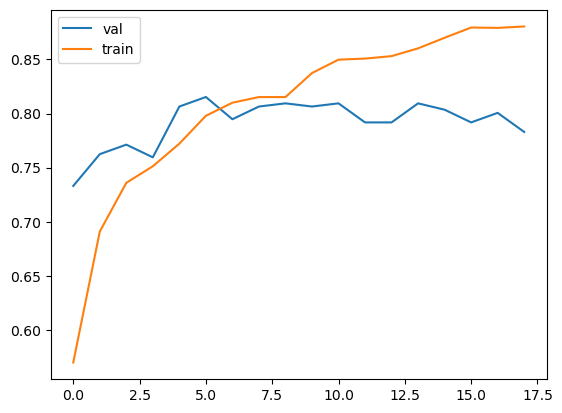

In [39]:
# Display of accuracy of the train & validation datasets after augumentation
hist = history.history

plt.plot(hist['val_accuracy'], label = 'val')
plt.plot(hist['accuracy'], label = 'train')

plt.legend()

# **Training The Large Model**

In [40]:
# The Large model 
def make_model(input_size = 150, learning_rate = 0.01, size_inner = 100, droprate = 0.5):
    base_model = Xception(
        weights = 'imagenet', 
        include_top = False, 
        input_shape = (input_size, input_size, 3)
    )
    base_model.trainable = False
    ##########################################################

    inputs = keras.Input(shape = (input_size, input_size, 3))
    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation = 'relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)

    ##########################################################
    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer, 
        loss = loss, 
        metrics = ['accuracy']
    )
    return model

#### **Updating the final large model with the upscaled data inputs**  

**The shape of the data change from (150 150 3) to (299 299, 3)**

In [41]:
# The inclusion of all optimized hyperparameter in the Large model
input_size = 299

train_gen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    shear_range = 10,
    zoom_range = 0.1,
    horizontal_flip = True 
)

train_ds = train_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\train', 
    target_size = (input_size, input_size), 
    batch_size = 34
)


val_gen = ImageDataGenerator(preprocessing_function = preprocess_input)

val_ds = val_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\validation', 
    target_size = (input_size, input_size), 
    batch_size = 34,
    shuffle = False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


#### **Adding CheckPoint Parameters to the Final Large Model**

In [42]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5', 
    save_best_only = True, 
    monitor = 'val_accuracy', 
    mode = 'max'
)

#### **Fitting the Large CNN Model (Training)**

In [43]:
learning_rate = 0.001
size = 100
droprate = 0.2
input_size = 299

model = make_model(
    input_size = 299,
    learning_rate = learning_rate, 
    size_inner = size,
    droprate = droprate
)
history = model.fit(train_ds, epochs = 18, validation_data = val_ds, callbacks=[checkpoint])


# Force an explicit manual save right after it finishes
model.save("final_second_run_model.keras")
print("Model successfully saved manually!")

Epoch 1/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7249 - loss: 0.8350

91/91 ━━━━━━━━━━━━━━━━━━━━ 770s 8s/step - accuracy: 0.7249 - loss: 0.8350 - val_accuracy: 0.8592 - val_loss: 0.4372
Epoch 2/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8419 - loss: 0.4575

91/91 ━━━━━━━━━━━━━━━━━━━━ 557s 6s/step - accuracy: 0.8419 - loss: 0.4575 - val_accuracy: 0.8622 - val_loss: 0.4355
Epoch 3/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 548s 6s/step - accuracy: 0.8631 - loss: 0.3796 - val_accuracy: 0.8504 - val_loss: 0.4287
Epoch 4/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8817 - loss: 0.3492

91/91 ━━━━━━━━━━━━━━━━━━━━ 560s 6s/step - accuracy: 0.8817 - loss: 0.3492 - val_accuracy: 0.8944 - val_loss: 0.3510
Epoch 5/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 579s 6s/step - accuracy: 0.8983 - loss: 0.2928 - val_accuracy: 0.8915 - val_loss: 0.3555
Epoch 6/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 566s 6s/step - accuracy: 0.9032 - loss: 0.2775 - val_accuracy: 0.8768 - val_loss: 0.3365
Epoch 7/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 565s 6s/step - accuracy: 0.9140 - loss: 0.2513 - val_accuracy: 0.8827 - val_loss: 0.3451
Epoch 8/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 584s 6s/step - accuracy: 0.9241 - loss: 0.2259 - val_accuracy: 0.8739 - val_loss: 0.3478
Epoch 9/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 546s 6s/step - accuracy: 0.9218 - loss: 0.2205 - val_accuracy: 0.8798 - val_loss: 0.3420
Epoch 10/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 543s 6s/step - accuracy: 0.9276 - loss: 0.1959 - val_accuracy: 0.8592 - val_loss: 0.3870
Epoch 11/18
91/91 ━━━━━━━━━━━━━━━━━━━━ 545s 6s/step - accuracy: 0.9358 - loss: 0.1834 - val_accuracy: 0.8768 - val_loss: 

In [92]:
# descriptive summary of model variable/parameters
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)          │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 10, 10, 2048)        │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_15          │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 100)                 │         204,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,479,212 (81.94 MB)

 Trainable params: 205,910 (804.34 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

 Optimizer params: 411,822 (1.57 MB)

## **Implementation: Using the Model for Image Classification/Identification**  

#### **Checkpoint saving on the large Model above shows that xception_v4_1_04_0.894.h5 has the highest val_accuracy.**  
#### **Hence, xception_v4_1_04_0.894.h5 is used as the large optimized model for the implementation**

In [44]:
# load the saved model from my computer
keras.models.load_model('xception_v4_1_04_0.894.h5')

<Functional name=functional_15, built=True>

#### **The test dataset: load sample**

In [45]:
# load the test dataset sample
test_gen = ImageDataGenerator(preprocessing_function = preprocess_input)

test_ds = test_gen.flow_from_directory(
    r'C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\test',
    target_size = (299, 299),
    batch_size = 32,
    shuffle = False    
)

Found 372 images belonging to 10 classes.


In [47]:
# Evaluation of the test dataset
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.8925 - loss: 0.2777


[0.27765294909477234, 0.8924731016159058]

#### **The evaluation accuracy gotten above [0.892] is almost equivalent to the model accuracy [0.894]**

In [70]:
# declaring the image path
path = r"C:\Users\onyxj\OneDrive\Desktop\Demo.python\clothing-dataset-small-master\test\pants\0dfec862-c49f-430b-a6ef-c7ceb187225e.jpg"

# loading the image and assigning it to a variable 'img'
img = load_img(path, target_size = (299, 299, 3))

# converting the image to a numpy array and assigning to a variable 'X'
x = np.array(img)
X = np.array([x])

# print the shape of X 
print(X.shape)

# the X variable is preprocessed
X = preprocess_input(X)     

# the model prediction 
pred = model.predict(X)      

(1, 299, 299, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [67]:
# declaring the class index
classes = ['dress', 
           'hat', 
           'longsleeve', 
           'outwear', 
           'pants', 
           'shirt', 
           'shoes', 
           'shorts', 
           'skirt', 
           't-shirt'
          ]

In [64]:
# prediction in arrary format
pred[0]

array([-4.723278 , -7.066382 , -2.1546829, -0.8536765, 11.860395 ,
       -1.4934725, -4.7882996,  3.6853013, -5.584116 , -9.028102 ],
      dtype=float32)

In [68]:
# zip the prediction and the class index together 
dict(zip(classes, pred[0]))

{'dress': np.float32(-4.723278),
 'hat': np.float32(-7.066382),
 'longsleeve': np.float32(-2.1546829),
 'outwear': np.float32(-0.8536765),
 'pants': np.float32(11.860395),
 'shirt': np.float32(-1.4934725),
 'shoes': np.float32(-4.7882996),
 'shorts': np.float32(3.6853013),
 'skirt': np.float32(-5.584116),
 't-shirt': np.float32(-9.028102)}

#### **As indicated in the dictionary above, the highest value is 11.660395 which corresponds to pants. Invariably, the model is predicting that the image is a pant**  
#### **lets load the image and verify truly whether it is a pant**

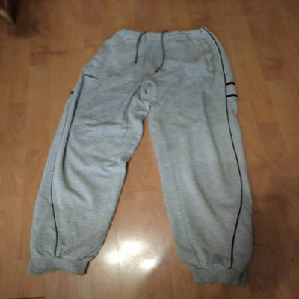

In [72]:
img

#### **The prediction is correct**

## **Model Application and Business Context**  
The model can applied to scale image identification in both industrial production for identification and tagging, it can also be used in modern automated production for seperation and detection of defects in finished products. This decreses manual labor input, scales production and efficiency, hence, reduces cost of production.
#### **Alternative application**
With modification, it can also be used in robotics, self driving vehicles, supper market tagging of product, medical imaging. In all these field of services, it helps in quality control, performance, efficiency and to boost the rate of production thereby enhanced economic profitability. 
#### **Result**  
The accuracy of the model is approximately 89% or 0.894, which is commendable. and model was able to identify different cloths with high precision.
